# Four-group sphericity workflow

This notebook is self-contained: it defines the analysis functions, generates missing shape data, and then plots the four-group comparison in one workflow.

Groups:

- $\text{IDP}_{50}$: `W_cluster/alhx_0`, `alhx_0_re1`, `alhx_0_re2`
- $\text{Hel}_{50}$: `W_cluster/alhx_700`, `alhx_700_re1`, `alhx_700_re2`
- $\text{IDP}_{50}$-Mem: `Onmem/muti_chain/POPC7-POPG3/alhx_0_plus1/2/3`
- $\text{Hel}_{10}\text{IDP}_{40}$-Mem: `Onmem/muti_chain/POPC7-POPG3/alhx_700_WALL1/2/3`

All systems use `TR_Mdvwhole/pbc.tpr` with `TR_Mdvwhole/clus_centered.xtc`. Because `pbc.tpr` does not separate the 50 protein chains as molecules, chains are reconstructed as consecutive 140-residue protein blocks.

Frame windows:

- Solution groups: previous setting, from frame `10000` to the end.
- IDP50-Mem group: all frames.
- Hel/700 membrane group: last half of each trajectory.

Use the `mdanalysis` conda environment for this notebook.

In [1]:
# 统一论文图的风格和尺寸, 方便后续拼接
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm   # 修改 1：新增，用于手动加载 Arial.ttf


# =========================
# 修改 2：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"   # 改成你的 arial.ttf 实际路径
USE_ARIAL_TTF = True                # True = 从 ttf 文件加载 Arial；False = 直接用系统字体名


_PUB_FONT_NAME = None


def load_pub_font():
    """
    手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。
    这样可以避免系统装了 Arial 但 matplotlib 仍然找不到的问题。
    """
    global _PUB_FONT_NAME

    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME

    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")

        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"

    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single": 100,
    "double": 200,
}


FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}


_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()   # 修改 3：每次设置风格前，先确保 Arial.ttf 已经加载

    base = {
        # 修改 4：不再直接写死 "Arial"，而是使用 ttf 文件真实识别到的字体名
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],

        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        # 让 $...$ 数学文本也尽量使用同一套 Arial 字体，避免最后几张图混入 DejaVu。
        "mathtext.fontset": "custom",
        "mathtext.rm": pub_font,
        "mathtext.it": pub_font,
        "mathtext.bf": pub_font,
        "mathtext.default": "regular",

        # 稍粗一些的论文图风格
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",

        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,

        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,

        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,

        "savefig.dpi": 300,
        "figure.dpi": 120,
    }

    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=300, tight=False, pad_inches=0.02):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=pad_inches)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

Using font: Arial


In [2]:
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

try:
    import MDAnalysis as mda
    from MDAnalysis.lib.distances import distance_array
except Exception:  # pragma: no cover - handled at runtime for notebook users.
    mda = None
    distance_array = None


ROOT = Path(
    "/data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/"
    "Martini_alhx/mdrun/M3IDP"
)
DATA_DIR = ROOT / "Analysis/Sphericity"
W_CLUSTER_DIR = ROOT / "W_cluster"
MEMBRANE_DIR = ROOT / "Onmem/muti_chain/POPC7-POPG3"

ARIAL_TTF_PATH = Path("/data/jychen/package/Arial/arial.ttf")
RESIDUES_PER_CHAIN = 140
CONTACT_SELECTION = "protein and name BB"
CONTACT_CUTOFF_A = 8.0


@dataclass(frozen=True)
class RunConfig:
    group_key: str
    group_name: str
    plain_group_name: str
    color: str
    replicate: str
    run_dir: Path
    output_file: Path
    start_frame: int | str
    end_frame: int | None = None
    topology_name: str = "pbc.tpr"
    trajectory_name: str = "clus_centered.xtc"

    @property
    def topology_file(self) -> Path:
        return self.run_dir / "TR_Mdvwhole" / self.topology_name

    @property
    def trajectory_file(self) -> Path:
        return self.run_dir / "TR_Mdvwhole" / self.trajectory_name


GROUP_INFO = {
    "sol_idp": {
        "group_name": r"$\text{IDP}_{50}$",
        "plain_group_name": "IDP50",
        "color": "#4C78A8",
    },
    "sol_hel": {
        "group_name": r"$\text{Hel}_{50}$",
        "plain_group_name": "Hel50",
        "color": "#F58518",
    },
    "mem_idp": {
        "group_name": r"$\text{IDP}_{50}$-Mem",
        "plain_group_name": "IDP50-Mem",
        "color": "#54A24B",
    },
    "mem_hel": {
        "group_name": r"$\text{Hel}_{10}\text{IDP}_{40}$-Mem",
        "plain_group_name": "Hel10IDP40-Mem",
        "color": "#B279A2",
    },
}
GROUP_ORDER = ["sol_idp", "sol_hel", "mem_idp", "mem_hel"]


def _make_run(
    group_key: str,
    replicate: str,
    run_dir: Path,
    output_name: str,
    start_frame: int | str,
    end_frame: int | None = None,
) -> RunConfig:
    info = GROUP_INFO[group_key]
    return RunConfig(
        group_key=group_key,
        group_name=info["group_name"],
        plain_group_name=info["plain_group_name"],
        color=info["color"],
        replicate=replicate,
        run_dir=run_dir,
        output_file=DATA_DIR / output_name,
        start_frame=start_frame,
        end_frame=end_frame,
    )


def get_run_configs() -> list[RunConfig]:
    runs: list[RunConfig] = []

    solution_idp = [
        ("rep1", "alhx_0", "alhx_0.txt"),
        ("rep2", "alhx_0_re1", "alhx_0_re1.txt"),
        ("rep3", "alhx_0_re2", "alhx_0_re2.txt"),
    ]
    solution_hel = [
        ("rep1", "alhx_700", "alhx_700.txt"),
        ("rep2", "alhx_700_re1", "alhx_700_re1.txt"),
        ("rep3", "alhx_700_re2", "alhx_700_re2.txt"),
    ]
    membrane_idp = [
        ("rep1", "alhx_0_plus1", "popc7popg3_alhx_0_plus1.txt"),
        ("rep2", "alhx_0_plus2", "popc7popg3_alhx_0_plus2.txt"),
        ("rep3", "alhx_0_plus3", "popc7popg3_alhx_0_plus3.txt"),
    ]
    membrane_hel = [
        ("rep1", "alhx_700_WALL1", "popc7popg3_alhx_700_WALL1.txt"),
        ("rep2", "alhx_700_WALL2", "popc7popg3_alhx_700_WALL2.txt"),
        ("rep3", "alhx_700_WALL3", "popc7popg3_alhx_700_WALL3.txt"),
    ]

    for rep, dirname, output_name in solution_idp:
        runs.append(_make_run("sol_idp", rep, W_CLUSTER_DIR / dirname, output_name, 10000))
    for rep, dirname, output_name in solution_hel:
        runs.append(_make_run("sol_hel", rep, W_CLUSTER_DIR / dirname, output_name, 10000))

    # Membrane IDP is analyzed over all frames. Membrane Hel/700 is analyzed over
    # the last half of each trajectory.
    for rep, dirname, output_name in membrane_idp:
        runs.append(_make_run("mem_idp", rep, MEMBRANE_DIR / dirname, output_name, 0, None))
    for rep, dirname, output_name in membrane_hel:
        runs.append(_make_run("mem_hel", rep, MEMBRANE_DIR / dirname, output_name, "half", None))

    return runs


def require_mdanalysis() -> None:
    if mda is None or not hasattr(mda, "Universe") or distance_array is None:
        raise RuntimeError(
            "MDAnalysis is not available in this Python environment. "
            "Run with /home/jychen/anaconda3/envs/mdanalysis/bin/python, "
            "or use a Jupyter kernel from the mdanalysis conda environment."
        )


def mm_to_inch(mm: float) -> float:
    return mm / 25.4

def set_pub_style() -> None:
    font_name = "Arial"
    if ARIAL_TTF_PATH.exists():
        fm.fontManager.addfont(str(ARIAL_TTF_PATH))
        font_name = fm.FontProperties(fname=str(ARIAL_TTF_PATH)).get_name()

    mpl.rcParams.update(
        {
            "font.family": font_name,
            "font.sans-serif": [
                font_name,
                "Arial",
                "Helvetica",
                "Liberation Sans",
                "DejaVu Sans",
            ],
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
            "axes.linewidth": 1.5,
            "xtick.major.width": 1.4,
            "ytick.major.width": 1.4,
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.major.size": 4.5,
            "ytick.major.size": 4.5,
            "lines.linewidth": 1.7,
            "patch.linewidth": 1.3,
            "legend.frameon": False,
            "legend.fontsize": 10,
            "font.size": 11,
            "axes.labelsize": 12,
            "axes.titlesize": 12,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "axes.unicode_minus": False,
            "savefig.dpi": 300,
            "figure.dpi": 120,
        }
    )


def validate_input_files(runs: list[RunConfig] | None = None) -> list[dict[str, object]]:
    rows = []
    for run in runs or get_run_configs():
        rows.append(
            {
                "group": run.plain_group_name,
                "replicate": run.replicate,
                "topology": run.topology_file,
                "topology_exists": run.topology_file.exists(),
                "trajectory": run.trajectory_file,
                "trajectory_exists": run.trajectory_file.exists(),
                "output": run.output_file,
                "output_exists": run.output_file.exists(),
            }
        )
    return rows


def split_protein_chains_by_residue_blocks(
    universe,
    residues_per_chain: int = RESIDUES_PER_CHAIN,
    protein_selection: str = "protein",
) -> list:
    protein = universe.select_atoms(protein_selection)
    residues = protein.residues
    n_residues = len(residues)
    if n_residues == 0:
        raise ValueError(f"Selection {protein_selection!r} found no protein residues.")
    if n_residues % residues_per_chain != 0:
        raise ValueError(
            f"Protein has {n_residues} residues, which is not divisible by "
            f"residues_per_chain={residues_per_chain}."
        )
    return [
        residues[start : start + residues_per_chain].atoms
        for start in range(0, n_residues, residues_per_chain)
    ]


def chain_split_diagnostics(run: RunConfig) -> dict[str, object]:
    require_mdanalysis()
    u = mda.Universe(str(run.topology_file), str(run.trajectory_file))
    protein = u.select_atoms("protein")
    bb = u.select_atoms(CONTACT_SELECTION)
    chains = split_protein_chains_by_residue_blocks(u)
    try:
        molecule_count = len(protein.split("molecule"))
    except Exception:
        molecule_count = None
    return {
        "group": run.plain_group_name,
        "replicate": run.replicate,
        "frames": len(u.trajectory),
        "protein_atoms": len(protein),
        "protein_residues": len(protein.residues),
        "bb_atoms": len(bb),
        "residue_block_chains": len(chains),
        "split_molecule_chains": molecule_count,
        "first_resid": int(protein.residues.resids[0]),
        "last_resid": int(protein.residues.resids[-1]),
    }


def calculate_gyration_tensor(atomgroup) -> np.ndarray:
    positions = atomgroup.positions.astype(float)
    com = atomgroup.center_of_mass()
    rel_pos = positions - com
    masses = getattr(atomgroup, "masses", None)
    if masses is None or np.sum(masses) <= 0:
        masses = np.ones(len(atomgroup), dtype=float)
    total_mass = np.sum(masses)
    return np.dot(rel_pos.T * masses, rel_pos) / total_mass


def find_clusters(adj_matrix: np.ndarray) -> list[list[int]]:
    visited = np.zeros(len(adj_matrix), dtype=bool)
    clusters: list[list[int]] = []
    for start in range(len(adj_matrix)):
        if visited[start]:
            continue
        cluster = []
        queue = [start]
        visited[start] = True
        while queue:
            current = queue.pop(0)
            cluster.append(current)
            neighbors = np.where(adj_matrix[current] & ~visited)[0]
            for neighbor in neighbors:
                visited[neighbor] = True
                queue.append(int(neighbor))
        clusters.append(cluster)
    return clusters


def analyze_current_frame(
    universe,
    chains: list,
    cutoff_distance: float = CONTACT_CUTOFF_A,
    contact_selection: str = CONTACT_SELECTION,
    use_pbc_distance: bool = True,
) -> dict[str, float]:
    num_chains = len(chains)
    contact_groups = [chain.select_atoms(contact_selection) for chain in chains]
    adj_matrix = np.zeros((num_chains, num_chains), dtype=bool)
    box = universe.trajectory.ts.dimensions if use_pbc_distance else None

    for i in range(num_chains):
        pos_i = contact_groups[i].positions
        if len(pos_i) == 0:
            continue
        for j in range(i + 1, num_chains):
            pos_j = contact_groups[j].positions
            if len(pos_j) == 0:
                continue
            distances = distance_array(pos_i, pos_j, box=box)
            if np.any(distances < cutoff_distance):
                adj_matrix[i, j] = True
                adj_matrix[j, i] = True

    clusters = find_clusters(adj_matrix)
    largest_cluster = max(clusters, key=len)
    largest_cluster_atoms = sum((chains[idx] for idx in largest_cluster), universe.atoms[[]])

    try:
        largest_cluster_atoms.unwrap(reference="geometry")
    except Exception:
        pass

    tensor = calculate_gyration_tensor(largest_cluster_atoms)
    eigvals = np.linalg.eigvalsh(tensor)
    eigvals = np.clip(np.sort(eigvals), 0.0, None)
    l_min, l_mid, l_maj = np.sqrt(eigvals)
    rg_sq = float(np.sum(eigvals))
    rg = float(np.sqrt(rg_sq))

    if rg_sq <= 0:
        kappa2 = 0.0
    else:
        lx2, ly2, lz2 = eigvals
        numerator = lx2 * ly2 + ly2 * lz2 + lz2 * lx2
        kappa2 = float(1.0 - 3.0 * numerator / (rg_sq**2))

    return {
        "time_ns": float(universe.trajectory.ts.time / 1000.0),
        "kappa2": kappa2,
        "rg": rg,
        "cluster_size": float(len(largest_cluster)),
        "l_min": float(l_min),
        "l_mid": float(l_mid),
        "l_maj": float(l_maj),
    }


def analyze_run(
    run: RunConfig,
    stride: int = 1,
    max_frames: int | None = None,
    write_output: bool = True,
    overwrite: bool = False,
    verbose: bool = True,
) -> np.ndarray:
    require_mdanalysis()
    if run.output_file.exists() and write_output and not overwrite:
        if verbose:
            print(f"Skip existing output: {run.output_file}")
        return load_shape_array(run.output_file)

    u = mda.Universe(str(run.topology_file), str(run.trajectory_file))
    chains = split_protein_chains_by_residue_blocks(u)
    end_frame = len(u.trajectory) if run.end_frame is None else min(run.end_frame, len(u.trajectory))
    if run.start_frame == "half":
        start_frame = end_frame // 2
    else:
        start_frame = int(run.start_frame)
    frame_indices = list(range(start_frame, end_frame, stride))
    if max_frames is not None:
        frame_indices = frame_indices[:max_frames]
    if not frame_indices:
        raise ValueError(
            f"No frames selected for {run.plain_group_name} {run.replicate}: "
            f"start={run.start_frame}, resolved_start={start_frame}, end={run.end_frame}, stride={stride}, "
            f"trajectory_frames={len(u.trajectory)}"
        )

    rows = []
    if verbose:
        print(
            f"{run.plain_group_name} {run.replicate}: "
            f"{len(chains)} chains, {len(frame_indices)} frames"
        )
    for count, frame_index in enumerate(frame_indices, start=1):
        u.trajectory[frame_index]
        result = analyze_current_frame(u, chains)
        rows.append(
            [
                result["time_ns"],
                result["kappa2"],
                result["rg"],
                result["cluster_size"],
                result["l_min"],
                result["l_mid"],
                result["l_maj"],
            ]
        )
        if verbose:
            print(
                f"  frame {frame_index} ({count}/{len(frame_indices)}): "
                f"size={result['cluster_size']:.0f}, kappa2={result['kappa2']:.4f}"
            )

    data = np.asarray(rows, dtype=float)
    if write_output:
        run.output_file.parent.mkdir(parents=True, exist_ok=True)
        avg_k = np.nanmean(data[:, 1])
        std_k = np.nanstd(data[:, 1])
        header = (
            "Time(ns) Kappa2 Rg(A) Size L_minor(A) L_mid(A) L_major(A)\n"
            f"Generated from {run.trajectory_file}\n"
            f"Topology {run.topology_file}\n"
            f"Chain split: protein residues in blocks of {RESIDUES_PER_CHAIN}\n"
            f"AvgKappa2={avg_k:.4f}+-{std_k:.4f}"
        )
        np.savetxt(run.output_file, data, header=header, fmt="%.4f")
        if verbose:
            print(f"Saved: {run.output_file}")
    return data


def load_shape_array(path: Path) -> np.ndarray:
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return data


def load_shape_record(run: RunConfig) -> dict[str, object]:
    data = load_shape_array(run.output_file)
    return {
        "run": run,
        "group_key": run.group_key,
        "group_name": run.group_name,
        "plain_group_name": run.plain_group_name,
        "color": run.color,
        "replicate": run.replicate,
        "filename": run.output_file.name,
        "time_ns": data[:, 0],
        "time_us": data[:, 0] / 1000.0,
        "kappa2": data[:, 1],
        "rg": data[:, 2],
        "size": data[:, 3],
        "l_min": data[:, 4],
        "l_mid": data[:, 5],
        "l_maj": data[:, 6],
    }


def load_available_records(
    runs: list[RunConfig] | None = None,
) -> tuple[list[dict[str, object]], list[RunConfig]]:
    records = []
    missing = []
    for run in runs or get_run_configs():
        if run.output_file.exists():
            records.append(load_shape_record(run))
        else:
            missing.append(run)
    return records, missing


def record_mean(record: dict[str, object], key: str) -> float:
    return float(np.nanmean(record[key]))


def finite_concat(records: list[dict[str, object]], keys: tuple[str, ...] | list[str]) -> np.ndarray:
    arrays = []
    for record in records:
        for key in keys:
            values = np.asarray(record[key], dtype=float)
            values = values[np.isfinite(values)]
            if values.size:
                arrays.append(values)
    if not arrays:
        return np.asarray([], dtype=float)
    return np.concatenate(arrays)


def padded_limits(values: np.ndarray, pad_fraction: float = 0.05, min_pad: float = 0.5) -> tuple[float, float] | None:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None
    lower = float(np.nanmin(values))
    upper = float(np.nanmax(values))
    pad = max(min_pad, pad_fraction * (upper - lower))
    return lower - pad, upper + pad


def _plot_group_metric(ax, records: list[dict[str, object]], metric_key: str, ylabel: str) -> None:
    x_positions = np.arange(len(GROUP_ORDER))
    means = []
    stds = []
    colors = []
    for group_key in GROUP_ORDER:
        group_records = [record for record in records if record["group_key"] == group_key]
        vals = np.array([record_mean(record, metric_key) for record in group_records], dtype=float)
        means.append(np.nanmean(vals) if vals.size else np.nan)
        stds.append(np.nanstd(vals, ddof=1) if vals.size > 1 else 0.0)
        colors.append(GROUP_INFO[group_key]["color"])

    ax.bar(
        x_positions,
        means,
        yerr=stds,
        width=0.62,
        color=colors,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.86,
        capsize=4,
        error_kw=dict(ecolor="black", lw=1.2, capthick=1.2),
        zorder=2,
    )

    jitter = np.array([-0.16, 0.0, 0.16, 0.08, -0.08])
    for group_index, group_key in enumerate(GROUP_ORDER):
        group_records = [record for record in records if record["group_key"] == group_key]
        for rep_index, record in enumerate(group_records):
            xpos = group_index + jitter[rep_index % len(jitter)]
            ax.scatter(
                xpos,
                record_mean(record, metric_key),
                s=24,
                facecolor="white",
                edgecolor="black",
                linewidth=1.0,
                zorder=4,
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [GROUP_INFO[key]["group_name"] for key in GROUP_ORDER],
        rotation=28,
        ha="right",
        rotation_mode="anchor",
    )
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.tick_params(top=False, right=False)


def make_four_group_summary_figure(
    records: list[dict[str, object]],
    output_path: Path = DATA_DIR / "sphericity_four_group_summary.png",
) -> Path:
    if "new_subplots" not in globals():
        raise RuntimeError("请先运行固定绘图格式 cell，其中定义了 new_subplots 和 FIG_PRESETS。")
    fig, ax = new_subplots(1, 1, preset="single_medium")
    _plot_group_metric(ax, records, "kappa2", r"$\kappa^2$")
    fig.subplots_adjust(left=0.20, right=0.95, bottom=0.34, top=0.94)
    if "savefig_pub" in globals():
        savefig_pub(fig, output_path)
    else:
        fig.savefig(output_path, dpi=300)
    return output_path


def make_axis_comparison_figure(
    records: list[dict[str, object]],
    output_path: Path = DATA_DIR / "sphericity_axis_four_group_summary.png",
) -> Path:
    if "new_subplots" in globals():
        fig, axes = new_subplots(1, 3, preset="double_short")
    else:
        set_pub_style()
        fig, axes = plt.subplots(1, 3, figsize=(mm_to_inch(200), mm_to_inch(75)))
    metrics = [
        ("l_min", r"$L_{\mathrm{minor}}$ ($\AA$)"),
        ("l_mid", r"$L_{\mathrm{mid}}$ ($\AA$)"),
        ("l_maj", r"$L_{\mathrm{major}}$ ($\AA$)"),
    ]
    for ax, (metric_key, ylabel) in zip(axes, metrics):
        _plot_group_metric(ax, records, metric_key, ylabel)
        ax.set_ylim(0, 65)
        ax.set_yticks([0, 20, 40, 60])
    fig.subplots_adjust(left=0.075, right=0.995, bottom=0.26, top=0.94, wspace=0.38)
    if "savefig_pub" in globals():
        savefig_pub(fig, output_path)
    else:
        fig.savefig(output_path, dpi=300)
    return output_path


def make_time_axis_overview_figure(
    records: list[dict[str, object]],
    output_path: Path = DATA_DIR / "sphericity_four_group_time_axis_overview.png",
) -> Path:
    set_pub_style()
    nrows = len(records)
    if nrows == 0:
        raise ValueError("No records available for the time-axis overview figure.")

    row_height_mm = 30
    fig, axes = plt.subplots(
        nrows,
        6,
        figsize=(mm_to_inch(240), mm_to_inch(max(90, row_height_mm * nrows))),
        constrained_layout=True,
        sharex=False,
        gridspec_kw={"width_ratios": [1.25, 1.0, 1.0, 1.0, 1.0, 1.15]},
    )
    if nrows == 1:
        axes = np.asarray([axes])

    columns = [
        ("kappa2", r"$\kappa^2$", None),
        ("l_maj", r"$L_{\mathrm{major}}$ ($\AA$)", "#d62728"),
        ("l_mid", r"$L_{\mathrm{mid}}$ ($\AA$)", "#2ca02c"),
        ("l_min", r"$L_{\mathrm{minor}}$ ($\AA$)", "#1f77b4"),
    ]

    time_max = 0.0
    for record in records:
        time_rel = np.asarray(record["time_us"], dtype=float) - np.nanmin(record["time_us"])
        finite_time = time_rel[np.isfinite(time_rel)]
        if finite_time.size:
            time_max = max(time_max, float(np.nanmax(finite_time)))
    shared_xlim = (0.0, time_max) if time_max > 0 else None

    kappa_values = finite_concat(records, ("kappa2",))
    kappa_ylim = (0.0, 1.0)
    if kappa_values.size:
        kappa_ylim = (0.0, min(1.0, max(0.18, float(np.nanmax(kappa_values)) * 1.15)))

    metric_ylims = {
        "kappa2": kappa_ylim,
        "l_maj": padded_limits(finite_concat(records, ("l_maj",))),
        "l_mid": padded_limits(finite_concat(records, ("l_mid",))),
        "l_min": padded_limits(finite_concat(records, ("l_min",))),
    }

    length_xlim = padded_limits(finite_concat(records, ("l_maj", "l_mid", "l_min")))
    hist_bins = 30
    hist_edges = None
    dist_ymax = 0.0
    if length_xlim is not None:
        hist_edges = np.linspace(length_xlim[0], length_xlim[1], hist_bins + 1)
        for record in records:
            for key in ("l_maj", "l_mid", "l_min"):
                values = np.asarray(record[key], dtype=float)
                values = values[np.isfinite(values)]
                if values.size:
                    hist_values, _ = np.histogram(values, bins=hist_edges, density=True)
                    if hist_values.size and np.any(np.isfinite(hist_values)):
                        dist_ymax = max(dist_ymax, float(np.nanmax(hist_values)))
    dist_ylim = (0.0, dist_ymax * 1.10) if dist_ymax > 0 else None

    for row_index, record in enumerate(records):
        time_rel = record["time_us"] - np.nanmin(record["time_us"])
        row_label = (
            f"{record['plain_group_name']} {record['replicate']}\n"
            + rf"$\kappa^2$={record_mean(record, 'kappa2'):.3f}, "
            + rf"$N$={record_mean(record, 'size'):.1f}"
        )
        label_ax = axes[row_index, 0]
        label_ax.axis("off")
        if row_index == 0:
            label_ax.set_title("Run")
        label_ax.text(
            0.98,
            0.5,
            row_label,
            color=record["color"],
            ha="right",
            va="center",
            fontsize=8.5,
            linespacing=1.25,
            transform=label_ax.transAxes,
        )
        for col_index, (metric_key, ylabel, axis_color) in enumerate(columns):
            ax = axes[row_index, col_index + 1]
            color = record["color"] if axis_color is None else axis_color
            ax.plot(time_rel, record[metric_key], color=color, alpha=0.85, lw=1.1)
            if row_index == 0:
                ax.set_title(ylabel)
            if metric_ylims[metric_key] is not None:
                ax.set_ylim(metric_ylims[metric_key])
            if shared_xlim is not None:
                ax.set_xlim(shared_xlim)
            if row_index == nrows - 1:
                ax.set_xlabel(r"Time ($\mu$s)")
            ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
            ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
            ax.tick_params(top=False, right=False)

        ax_dist = axes[row_index, 5]
        hist_items = [
            ("l_maj", r"$L_{\mathrm{major}}$", "#d62728"),
            ("l_mid", r"$L_{\mathrm{mid}}$", "#2ca02c"),
            ("l_min", r"$L_{\mathrm{minor}}$", "#1f77b4"),
        ]
        for key, label, color in hist_items:
            values = np.asarray(record[key])
            values = values[~np.isnan(values)]
            if values.size:
                ax_dist.hist(
                    values,
                    bins=hist_edges if hist_edges is not None else hist_bins,
                    density=True,
                    alpha=0.45,
                    color=color,
                    histtype="stepfilled",
                    label=label,
                )
        if row_index == 0:
            ax_dist.set_title("Length distribution")
            ax_dist.legend(loc="best")
        if row_index == nrows - 1:
            ax_dist.set_xlabel(r"Length ($\AA$)")
        if row_index == nrows // 2:
            ax_dist.set_ylabel("Density")
        if length_xlim is not None:
            ax_dist.set_xlim(length_xlim)
        if dist_ylim is not None:
            ax_dist.set_ylim(dist_ylim)
        ax_dist.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
        ax_dist.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
        ax_dist.tick_params(top=False, right=False)

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return output_path


def make_all_figures(
    runs: list[RunConfig] | None = None,
    require_all: bool = True,
) -> tuple[list[Path], list[RunConfig]]:
    records, missing = load_available_records(runs)
    if require_all and missing:
        missing_names = ", ".join(run.output_file.name for run in missing)
        raise FileNotFoundError(f"Missing shape data files: {missing_names}")
    if not records:
        raise FileNotFoundError(f"No shape data files found in {DATA_DIR}")

    output_paths = [
        make_four_group_summary_figure(records),
        make_axis_comparison_figure(records),
        make_time_axis_overview_figure(records),
    ]
    return output_paths, missing


def run_smoke_test() -> list[dict[str, object]]:
    representative_runs = []
    for group_key in GROUP_ORDER:
        representative_runs.append(
            next(run for run in get_run_configs() if run.group_key == group_key and run.replicate == "rep1")
        )

    results = []
    for run in representative_runs:
        diagnostics = chain_split_diagnostics(run)
        smoke_run = RunConfig(
            group_key=run.group_key,
            group_name=run.group_name,
            plain_group_name=run.plain_group_name,
            color=run.color,
            replicate=run.replicate,
            run_dir=run.run_dir,
            output_file=run.output_file,
            start_frame=run.start_frame,
            end_frame=run.end_frame,
        )
        data = analyze_run(
            smoke_run,
            max_frames=1,
            write_output=False,
            overwrite=True,
            verbose=False,
        )
        diagnostics.update(
            {
                "smoke_kappa2": float(data[0, 1]),
                "smoke_cluster_size": float(data[0, 3]),
                "smoke_rg": float(data[0, 2]),
            }
        )
        results.append(diagnostics)
    return results


def print_input_table() -> None:
    for row in validate_input_files():
        status = "OK" if row["topology_exists"] and row["trajectory_exists"] else "MISSING"
        print(
            f"{status:7s} {row['group']:13s} {row['replicate']:4s} "
            f"top={row['topology_exists']} traj={row['trajectory_exists']} "
            f"out={row['output_exists']} {row['output'].name}"
        )


/home/jychen/anaconda3/envs/CJY/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Input check

This verifies that every configured run has `pbc.tpr` and `clus_centered.xtc`. Existing txt files are reused unless `OVERWRITE_EXISTING=True` in the workflow cell.

In [3]:
for row in validate_input_files():
    status = 'OK' if row['topology_exists'] and row['trajectory_exists'] else 'MISSING'
    print(
        f"{status:7s} {row['group']:13s} {row['replicate']:4s} "
        f"top={row['topology_exists']} traj={row['trajectory_exists']} "
        f"out={row['output_exists']} {row['output'].name}"
    )

OK      IDP50         rep1 top=True traj=True out=True alhx_0.txt
OK      IDP50         rep2 top=True traj=True out=True alhx_0_re1.txt
OK      IDP50         rep3 top=True traj=True out=True alhx_0_re2.txt
OK      Hel50         rep1 top=True traj=True out=True alhx_700.txt
OK      Hel50         rep2 top=True traj=True out=True alhx_700_re1.txt
OK      Hel50         rep3 top=True traj=True out=True alhx_700_re2.txt
OK      IDP50-Mem     rep1 top=True traj=True out=True popc7popg3_alhx_0_plus1.txt
OK      IDP50-Mem     rep2 top=True traj=True out=True popc7popg3_alhx_0_plus2.txt
OK      IDP50-Mem     rep3 top=True traj=True out=True popc7popg3_alhx_0_plus3.txt
OK      Hel10IDP40-Mem rep1 top=True traj=True out=True popc7popg3_alhx_700_WALL1.txt
OK      Hel10IDP40-Mem rep2 top=True traj=True out=True popc7popg3_alhx_700_WALL2.txt
OK      Hel10IDP40-Mem rep3 top=True traj=True out=True popc7popg3_alhx_700_WALL3.txt


## Small executable test

This loads one representative run per group and computes one frame without writing data. It checks the important part: `pbc.tpr` loads, residue-block chain splitting gives 50 chains, and largest-cluster shape calculation runs.

In [4]:
RUN_SMOKE_TEST = True

if RUN_SMOKE_TEST:
    for row in run_smoke_test():
        print(
            f"{row['group']:13s} {row['replicate']:4s} "
            f"chains(block)={row['residue_block_chains']} "
            f"chains(molecule)={row['split_molecule_chains']} "
            f"frames={row['frames']} "
            f"size={row['smoke_cluster_size']:.0f} "
            f"kappa2={row['smoke_kappa2']:.4f} "
            f"Rg={row['smoke_rg']:.2f}"
        )
else:
    print('Smoke test skipped.')

IDP50         rep1 chains(block)=50 chains(molecule)=1 frames=20001 size=50 kappa2=0.0178 Rg=73.49
Hel50         rep1 chains(block)=50 chains(molecule)=1 frames=20001 size=49 kappa2=0.1555 Rg=75.15
IDP50-Mem     rep1 chains(block)=50 chains(molecule)=1 frames=10001 size=48 kappa2=0.2049 Rg=84.41
Hel10IDP40-Mem rep1 chains(block)=50 chains(molecule)=1 frames=20001 size=41 kappa2=0.1571 Rg=81.45


## Generate data

This is the main cell. Existing txt files are loaded/skipped, and missing txt files are generated. Plotting is intentionally skipped here.

In [5]:
RUN_DATA = True
OVERWRITE_EXISTING = False
STRIDE = 1
MAX_FRAMES = None  # set a small integer, e.g. 5, only for a quick trial

# Plotting is handled by the final cell, so this cell only prepares/reuses data files.
PLOTTED_PATHS = []

if RUN_DATA:
    for run in get_run_configs():
        analyze_run(
            run,
            stride=STRIDE,
            max_frames=MAX_FRAMES,
            write_output=True,
            overwrite=OVERWRITE_EXISTING,
            verbose=True,
        )

    print()
    print('Data files are ready. Run the final cell to make and display figures.')
else:
    print('RUN_DATA=False, workflow skipped.')


Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_0.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_0_re1.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_0_re2.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_700.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_700_re1.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/alhx_700_re2.txt
Skip existing output: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Marti

## Plot and display figures

This cell creates the summary figures from the prepared txt data files and displays them in the notebook.

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


Saved: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/sphericity_four_group_summary.png
Saved: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/sphericity_axis_four_group_summary.png
Saved: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/Sphericity/sphericity_four_group_time_axis_overview.png


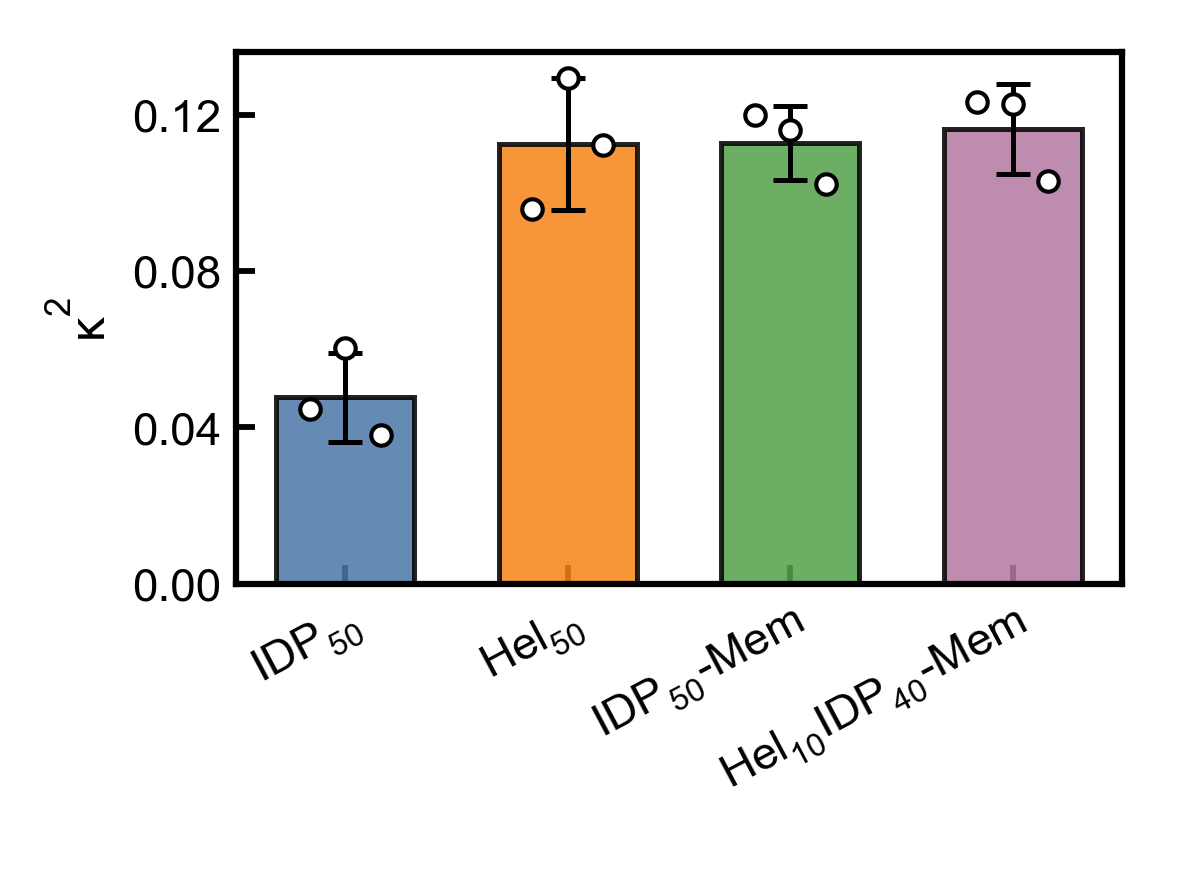

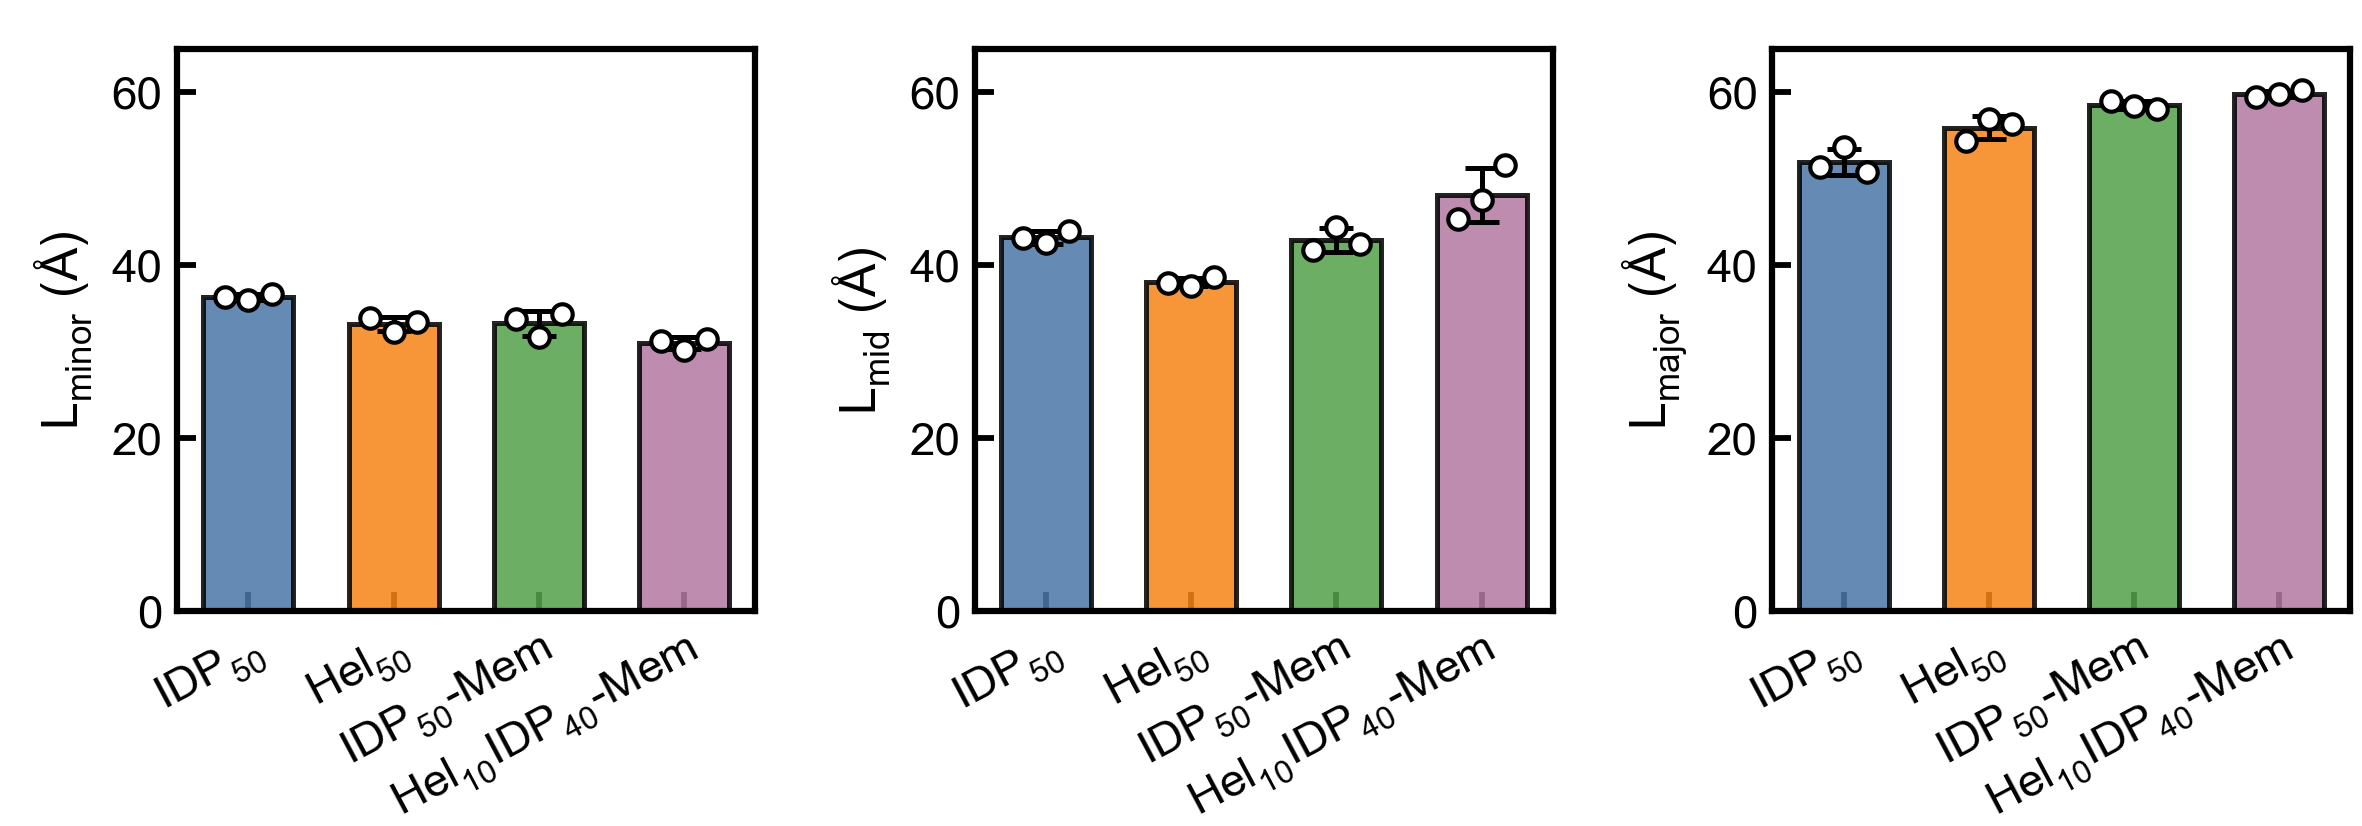

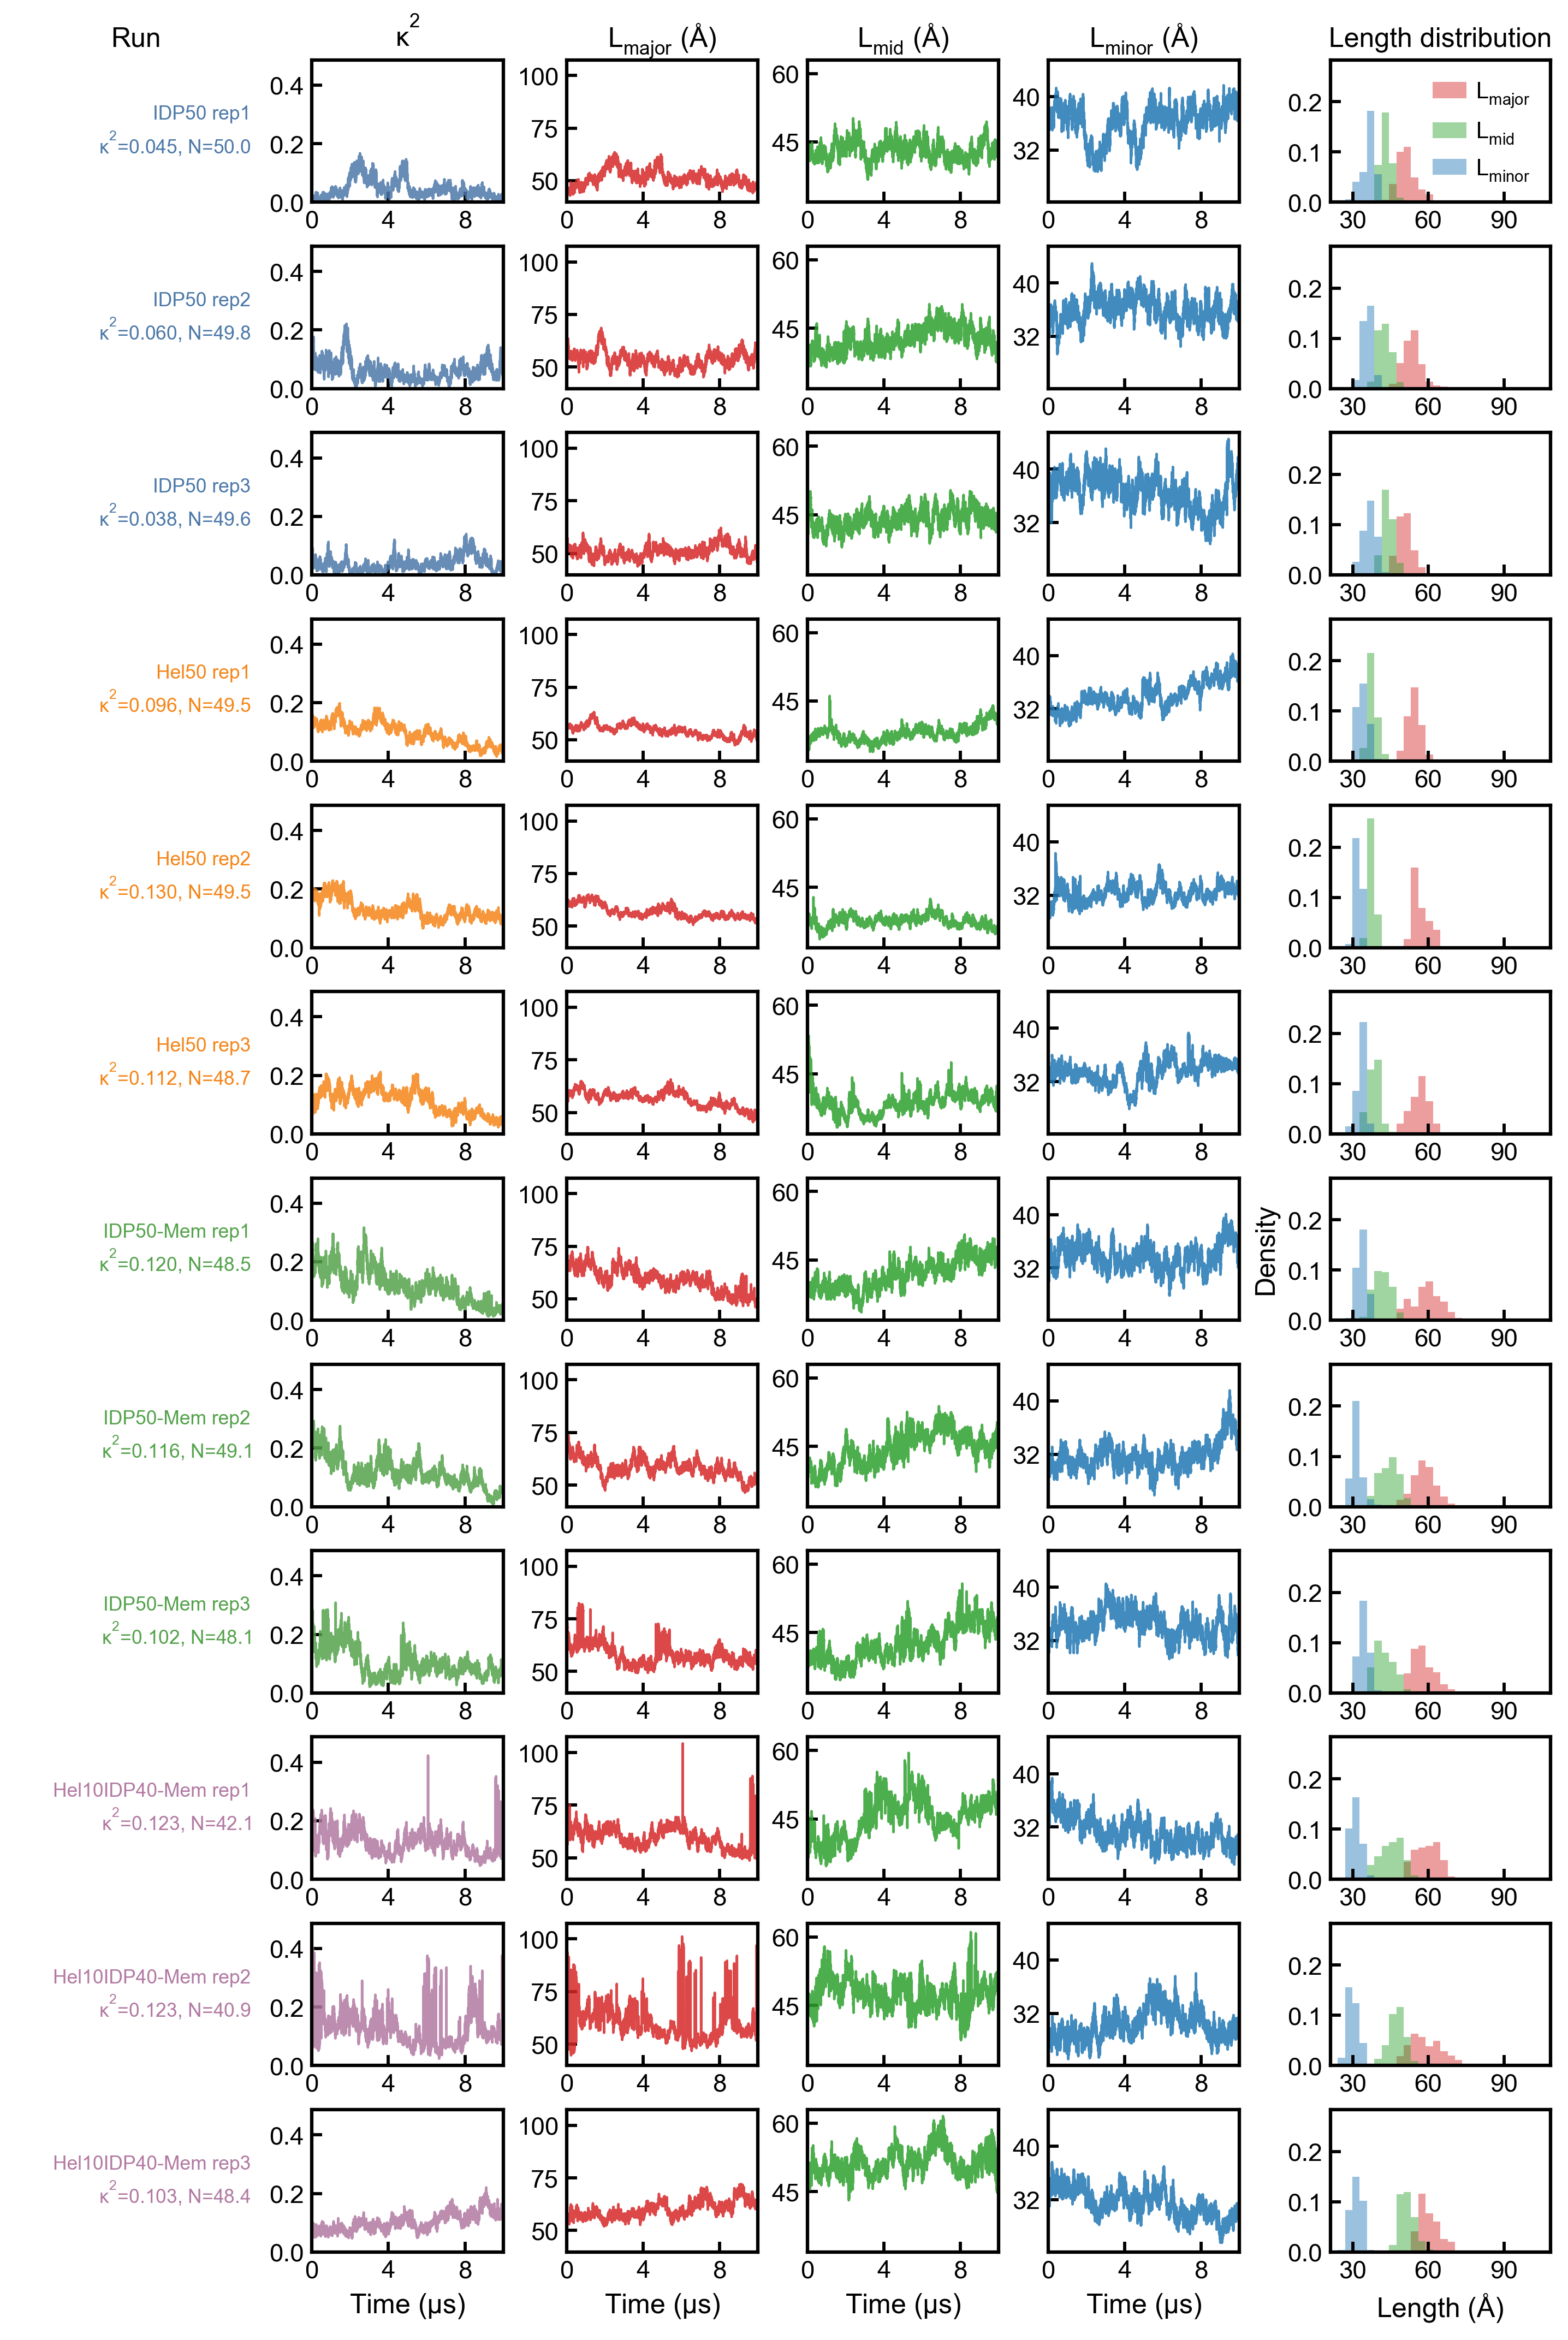

In [6]:
PLOT_FIGURES = True
ALLOW_PARTIAL_PLOTS = False

if PLOT_FIGURES:
    PLOTTED_PATHS, missing = make_all_figures(require_all=not ALLOW_PARTIAL_PLOTS)
    # The figure functions save PNG files but leave Matplotlib figures open.
    # Close them here so Jupyter does not auto-display a duplicate copy.
    plt.close("all")

    for path in PLOTTED_PATHS:
        print(f'Saved: {path}')

    if missing:
        print()
        print('Partial plot warning, missing data files:')
        for run in missing:
            print(f'  {run.output_file}')

    try:
        from IPython.display import Image, display
    except ImportError:
        Image = display = None

    for image_path in PLOTTED_PATHS:
        if display is None:
            print(f'Image saved: {image_path}')
        else:
            display(Image(filename=str(image_path)))
else:
    PLOTTED_PATHS = []
    print('PLOT_FIGURES=False, plotting skipped.')
